# FINAL PROJECT DESIGN: CWDM (de)multiplexer based on cascaded Mach-Zehnder Interferometers (MZIs)
### Sergi Pla Torró


En este proyecto implementamos el diseño, la simulación y el layout de un (de)multiplexer basado en MZIs en cascada. Primero se diseñan y simula el comportamiento de los distintos componentes. Después se genera la estructura total del circuito mediante SAX y finalmente se realiza el layout del circuito y se implementa en un die completo, con estructuras test y varias repeticiones de este.

## Parte 1: Diseño y simulación de componentes individuales


In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH
import sax
import jax.numpy as jnp

from upvfab_design_tools import MMI_EME, DC_EME
from scipy.interpolate import interp1d


nm = 1e-3
wavelength = np.linspace(1500, 1600,11) * nm
f = td.C_0 / wavelength
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

### 1.1) Simulación de modos en guías SOI


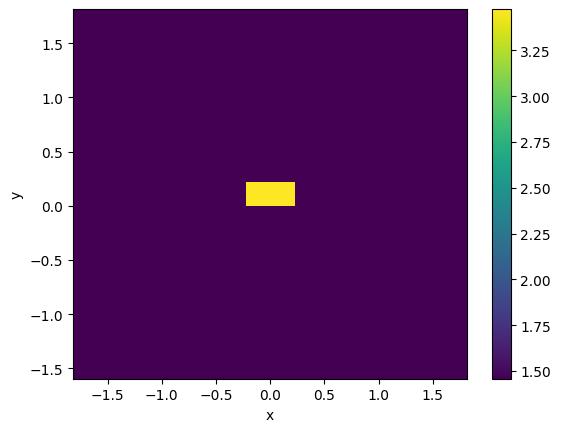

In [2]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=450*nm, # Waveguide width
    core_thickness=220 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=4, # Targeted number of modes to find 
    max_grid_scaling=1.5, # Parameters of the grid 
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

deep_waveguide.plot_index()

In [3]:
# we check if the modes are TE or TM polarized

deep_waveguide.fraction_te

2026-05-21 11:05:07.261 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_198a1ab0a96c4a6f.npz.


array([0.960726  , 0.06940437, 0.64309704, 0.99810644])

Mirando la fracción de modos TE, podemos decir que el primer modo fundamental es TE mientras que el segundo es TM. 

Text(0.5, 1.0, 'Modo 0 TE')

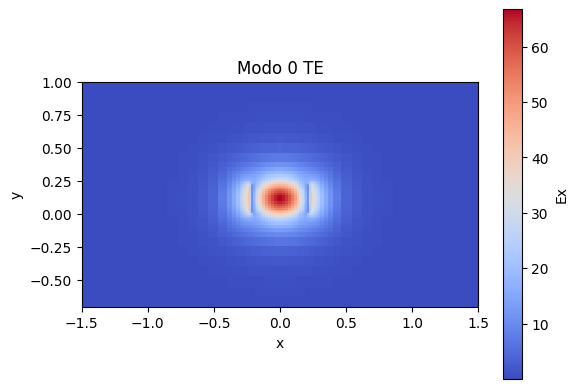

In [4]:
deep_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 
plt.title('Modo 0 TE') 

Text(0.5, 1.0, 'Modo 1 TM')

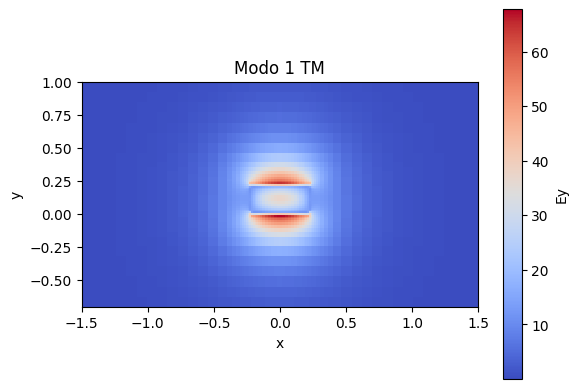

In [5]:
deep_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

plt.title('Modo 1 TM') 

In [6]:
# Calculamos los índices efectivos para un rango de longitudes de onda más grande (de 1.48 a 1.60 nm) interpolando el archivo de datos de neff SOI que tenemos
wvl_archivo = SOI[:, 0]
neff_450_TE_archivo = SOI[:, 3] 
neff_450_TM_archivo = SOI[:, 5] 

### Interpolación lineal:
 # Nuevo eje de longitudes de onda:
wvl = np.linspace(1.48, 1.60, 1000) 

# Funciones de interpolación lineal para TE y TM usando scipy.interpolate.interp1d
interp_neffu_TE = interp1d(
    wvl_archivo, neff_450_TE_archivo,
    kind='linear',
    fill_value="extrapolate",
    bounds_error=False
)

interp_neffu_TM = interp1d(
    wvl_archivo, neff_450_TM_archivo,
    kind='linear',
    fill_value="extrapolate",
    bounds_error=False
)

# Obtenemos los índices efectivos interpolados para el nuevo eje de longitudes de onda
neff_450_TE = interp_neffu_TE(wvl)
neff_450_TM = interp_neffu_TM(wvl)

# Calculamos los índices de grupo a partir de los índices efectivos interpolados
ng_450_TE = neff_450_TE - wvl * np.gradient(neff_450_TE, wvl)
ng_450_TM = neff_450_TM - wvl * np.gradient(neff_450_TM, wvl)

for wl, neff, ng in zip(wvl, neff_450_TE, ng_450_TE):
    print(f"wavelength = {wl} um   neff = {neff} (TE)   ng = {ng}")

wavelength = 1.48 um   neff = 2.442739999999991 (TE)   ng = 4.277939999999663
wavelength = 1.4801201201201202 um   neff = 2.442591051051042 (TE)   ng = 4.277939999999668
wavelength = 1.4802402402402401 um   neff = 2.4424421021020932 (TE)   ng = 4.277939999999668
wavelength = 1.4803603603603603 um   neff = 2.442293153153144 (TE)   ng = 4.277939999999668
wavelength = 1.4804804804804805 um   neff = 2.442144204204195 (TE)   ng = 4.277939999999668
wavelength = 1.4806006006006005 um   neff = 2.4419952552552466 (TE)   ng = 4.277939999996975
wavelength = 1.4807207207207207 um   neff = 2.4418463063062976 (TE)   ng = 4.277939999999668
wavelength = 1.4808408408408409 um   neff = 2.4416973573573486 (TE)   ng = 4.277940000002362
wavelength = 1.4809609609609609 um   neff = 2.4415484084083996 (TE)   ng = 4.277939999999668
wavelength = 1.481081081081081 um   neff = 2.4413994594594506 (TE)   ng = 4.277939999999668
wavelength = 1.4812012012012012 um   neff = 2.4412505105105016 (TE)   ng = 4.277939999996

### 1.2) Diseño de Directional Couplers

Tenemos que fijar o el gap entre guías de los DC o su longitud, y barrer el otro parámetro para conseguir los coeficientes de acoplo que buscamos. Fijamos la longitud y variamos el gap

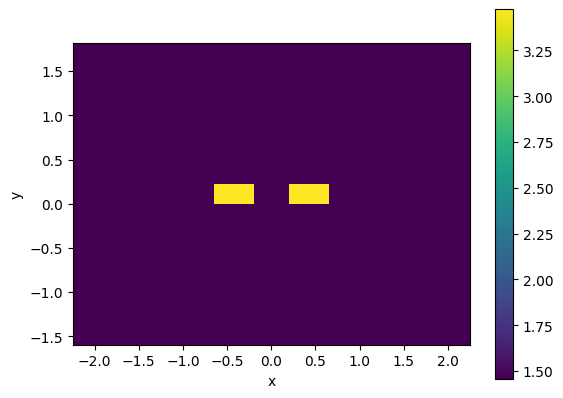

In [7]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(0.45, 0.45), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=220 * nm, # Waveguide height 
    gap=400*nm,
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

dcoupler_cs.plot_index()

In [8]:
dcoupler_neff = dcoupler_cs.n_eff
print(dcoupler_neff)

2026-05-21 11:05:07.543 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_d7d28029e1f4bec7.npz.
[2.35816142+6.53289443e-05j 2.33459217+7.01480984e-05j
 1.77349409+2.32176528e-04j 1.72117362+2.47894243e-04j]


In [9]:
dcoupler_cs.fraction_te

array([0.96692074, 0.96082553, 0.06235488, 0.07784008])

In [10]:
dcoupler_cs.fraction_tm

array([0.03307926, 0.03917447, 0.93764512, 0.92215992])

Sabemos que los dos primeros modos son TE y los demás son TM. Como normalmente diseñamos para el modo TE fundamental, realizamos los cálculos para TE0. Para diseñar los acopladores deseados, fijamos la separación entre las guías de onda en dcoupler_cs y después hacemos un barrido de la longitud del acoplador direccional para obtener los coeficientes de acoplo deseados.

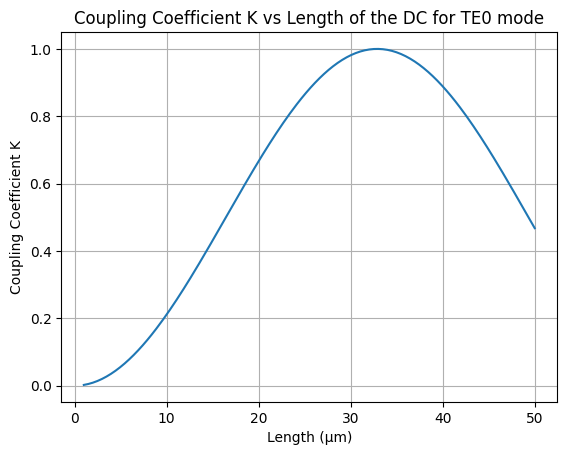

In [11]:
length_values = np.linspace(1.0,50,200)
results = []

# Lpi calculation for TE and TM modes with fixed gaps
L_pi_TE0 = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
L_pi_TM0 =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)

K_values = []

# We sweep the length values of the DC to obtain the desired coupling coefficients
for length in length_values:   
    K = (np.sin(1/2*np.pi*(length/L_pi_TE0)))**2
    K_values.append(K)

plt.plot(length_values, K_values)
plt.xlabel('Length (µm)')
plt.ylabel('Coupling Coefficient K')
plt.title('Coupling Coefficient K vs Length of the DC for TE0 mode')
plt.grid()
plt.show()

In [12]:
K_targets = [0.05, 0.17, 0.23, 0.3, 0.5]

print("Target coupling coefficients and corresponding DC lengths:")
for K_target in K_targets:
    L_target = (2 * L_pi_TE0 / np.pi) * np.arcsin(np.sqrt(K_target))
    print(f"K = {K_target:.2f}  ->  Length = {L_target:.4f} um")

Target coupling coefficients and corresponding DC lengths:
K = 0.05  ->  Length = 4.7207 um
K = 0.17  ->  Length = 8.8964 um
K = 0.23  ->  Length = 10.4704 um
K = 0.30  ->  Length = 12.1337 um
K = 0.50  ->  Length = 16.4409 um


### 1.3) MODELO SAX del circuito completo
Aquí presentamos el modelo de SAX que reproduce el circuito fotónico que queremos y proporciona la gráfica final del demultiplexor.

#### 1) Definimos los modelos que vamos a utilizar en el SAX: guías de onda y couplers para construir los diferentes MZI

In [13]:
# Waveguide Model

def waveguide(wl=1.55, neff=1.6072, length=10.0, loss=0.0) -> sax.SDict:
    phase = 2 * jnp.pi * neff * length / wl
    transmission = 10 ** (-loss * length / 20) * jnp.exp(1j * phase) # loss(dB/um)
    wg_dict = sax.reciprocal(
        {
            ("in0", "out0"): transmission,
        }
    )
    return wg_dict


# Coupler Model

def coupler(coupling=0.5) -> sax.SDict:
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict

markdown_text = r"""
#### 2) Calculamos las longitudes óptimas de los brazos de los MZI para que los FSR de S1 y S2 sean los correctos y que el circuito tenga el comportamiento que queremos
##### 2.1) Cálculo de longitudes para S1
Queremos que los 4 canales esten en:

$$
\lambda_1 = 1.51 \,\mu\text{m}
$$

$$
\lambda_2 = 1.53 \,\mu\text{m}
$$

$$
\lambda_3 = 1.55 \,\mu\text{m}
$$

$$
\lambda_4 = 1.57 \,\mu\text{m}
$$

Por lo que, el centro de los canales estará en:

$$
d_0 = \frac{1.57 + 1.51}{2} = 1.54 \,\mu\text{m}
$$

con una potencia de salida de:

$$
P_{\text{out}} = 0.5
$$

Utilizando la fórmula del MZI:

$$
I_0 = \frac{I_i}{2}\left(1 + \cos(\Delta \phi)\right)
$$

y fijando que la potencia de salida tiene que ser igual a la mitad de la potencia de entrada en esa longitud de onda, llegamos a:

$$
\Delta \phi = \frac{\pi}{2} + 2\pi m
$$

donde \(m\) es un entero.


Ahora, la diferencia de fase es:

$$
\Delta \phi(\lambda) = \beta \Delta L
$$

con:

$$
\beta = \frac{2\pi n_{\text{eff}}}{\lambda}
$$

Por lo que:

$$
\Delta \phi(\lambda) =
\frac{2\pi n_{\text{eff}}}{\lambda}\Delta L
$$

Despejando la diferencia de longitud entre brazos:


$$
\Delta L =
\frac{\Delta \phi(1.54)\cdot 1.54}
{2\pi n_{\text{eff}}(1.54)}
$$



Como en S1 tenemos tres bloques, la fase acumulada será:


$$
\Delta \phi =
3 \cdot \frac{2\pi n_{\text{eff}}}{\lambda_0}(L_1 - L_2)
$$

Por lo que finalmente obtenemos:

$$
L_1 - L_2 =
\frac{\lambda_0}{3 n_{\text{eff}}}
\left(m + \frac{1}{4}\right)
$$

Así que, fijando L2, L1 será:


$$
L_1 =
L_2 +
\frac{1.54\,\mu\text{m}}{3 n_{\text{eff}}}m
+
\frac{1.54\,\mu\text{m}}{12 n_{\text{eff}}}
$$

Además, se introduce un desfase adicional de $\pi$ para que cada longitud de onda salga por el puerto que queremos:


$$
\Delta L_{\pi} =
\frac{1.54\,\mu\text{m}}
{2 n_{\text{eff}}}
$$
"""

##### 2.2) Fijamos FSR de S1

Como queremos que S1 tenga un FSR de 40nm, una vez hemos calculado las longitudes óptimas de los MZI, tenemos que calcular el valor de m para que nos proporcione el valor de FSR que buscamos:

$$
\Delta L =
\frac{\lambda_0^2}{n_g \, FSR}
=
\left(m + \frac{1}{4}\right)
\frac{\lambda_0}{n_{\text{eff}}3} + \frac{\lambda_0}{n_{\text{eff}}2}
$$

Despejamos \(m\):

$$
m =
\frac{3\lambda_0 n_{\text{eff}}}{n_g \, FSR}
-
\frac{1}{4} + \frac{3}{2}
$$

##### 2.3) Cálculos para S2
Para S2 procedemos de la misma forma solo que ahora queremos separar las longitudes de onda de dos grupos: 1510 de 1550 nm y 1530 de 1570 nm. Hacemos los cálculos para la longitud central del primer grupo 1530 nm de la misma forma que para S1. Además, añadimos una longitud adicional correspondiente a un desfase de pi/2 al bloque de S2 de bajo del circuito.

In [14]:
# Elegimos el índice efectivo de la guía usada
TE0 = neff_450_TE

# Índices de longitud de onda 
idx_1530 = np.argmin(np.abs(wvl - 1.530))
idx_1540 = np.argmin(np.abs(wvl - 1.540))
idx_1550 = np.argmin(np.abs(wvl - 1.550))

# Cálculo de m para tener un FSR de 80nm y 40nm respectivamente

FSR = 40e-3
m1 = (3*wvl[idx_1540]*TE0[idx_1540])/(ng_450_TE[idx_1540]*FSR)-1/4+3/2
print(f'm para tener un FSR de 40nm: {m1}')

FSR = 80e-3
m2 = wvl[idx_1530]*TE0[idx_1530]/(ng_450_TE[idx_1530]*FSR)-1/4
print(f'm para tener un FSR de 80nm: {m2}')

m para tener un FSR de 40nm: 64.96196549828274
m para tener un FSR de 80nm: 10.393316871428155


In [15]:

# S1

m1 = 65
l2_s1 = 10.0

pi_s1 = wvl[idx_1540] / (2 * TE0[idx_1540])

l1_s1 = (
    wvl[idx_1540] / (3 * TE0[idx_1540]) * m1
    + wvl[idx_1540] / (12 * TE0[idx_1540])
    + l2_s1
    + pi_s1
)

k_s1 = [0.5, 0.17, 0.23, 0.05]


# S2

m2 = 10
l1_s2 = 5.0

despl_s2_up = wvl[idx_1550] / (2 * TE0[idx_1550])
despl_s2_b = wvl[idx_1530] / (4 * TE0[idx_1530])

l2_s2 = (
    m2 * wvl[idx_1530] / TE0[idx_1530]
    + wvl[idx_1530] / (4 * TE0[idx_1530])
    + l1_s2
    + despl_s2_up
)

k_s2 = [0.5, 0.3, 0.05]

print("S1:")
print("l1_s1 =", l1_s1)
print("l2_s1 =", l2_s1)


print("\nS2:")
print("l1_s2 =", l1_s2)
print("l2_s2 up =", l2_s2)
print("l2_s2 bottom =", l2_s2 + despl_s2_b)


S1:
l1_s1 = 24.4674054040168
l2_s1 = 10.0

S2:
l1_s2 = 5.0
l2_s2 up = 11.915996363576742
l2_s2 bottom = 12.076655028532878


#### 3) Creamos los modelos de SAX 

##### 3.1) Modelo de S1

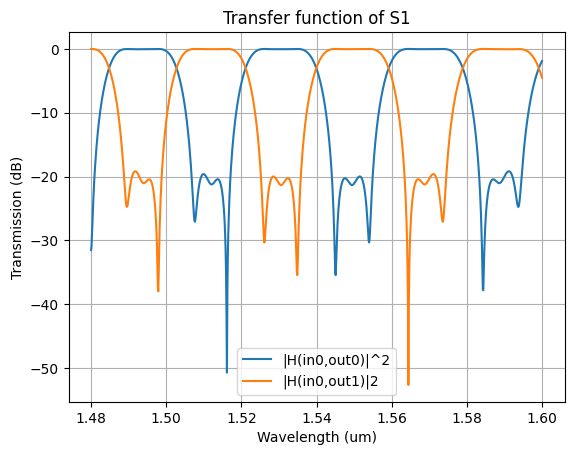

In [16]:
# DESIGN OF S1

L1 = 24.4674054040168
L2 = 10

neffu = neff_450_TE # en el pdf indica que suponemos misma anchura de guias
neffd = neff_450_TE

lambda0 = 1.55  # um
n1_1550 = np.interp(lambda0, wvl, neffu)

Lpi_s1 = float(wvl[idx_1540] / (2 * TE0[idx_1540]))

alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.17)
K_c = np.full(wvl.shape, 0.23)
K_d = np.full(wvl.shape, 0.05)

s1_model, info = sax.circuit(
    netlist={
        "instances": {
            "coup_a": "coupler",
            "wvg_u1": "waveguide",
            "wvg_d1": "waveguide",
            "coup_b": "coupler",

            "mid_u": "waveguide",
            "mid_d": "waveguide",

            "coup_c": "coupler",
            "wvg_u2": "waveguide",
            "wvg_d2": "waveguide",
            "coup_d": "coupler",
        },
        "connections": {
            # Coupler a, b
            "coup_a,out0": "wvg_u1,in0",
            "wvg_u1,out0": "coup_b,in0",
            "coup_a,out1": "wvg_d1,in0",
            "wvg_d1,out0": "coup_b,in1",

            # Coupler b, c
            "coup_b,out0": "mid_u,in0",
            "mid_u,out0": "coup_c,in0",
            "coup_b,out1": "mid_d,in0",
            "mid_d,out0": "coup_c,in1",

            # Coupler c, d
            "coup_c,out0": "wvg_u2,in0",
            "wvg_u2,out0": "coup_d,in0",
            "coup_c,out1": "wvg_d2,in0",
            "wvg_d2,out0": "coup_d,in1",
        },
        "ports": {
            "in0": "coup_a,in0",
            "in1": "coup_a,in1",
            "out0": "coup_d,out0",
            "out1": "coup_d,out1",
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

total_s1 = s1_model(
    wl=wvl,
    coup_a={"coupling": K_a},
    wvg_u1={"wl": wvl, "neff": neffu, "length": L1, "loss": alphau},
    wvg_d1={"wl": wvl, "neff": neffd, "length": L2, "loss": alphad},
    coup_b={"coupling": K_b},
    mid_d={"wl": wvl, "neff": neffd, "length": 2*L1, "loss": alphad},
    mid_u={"wl": wvl, "neff": neffu, "length": 2*L2, "loss": alphau},
    coup_c={"coupling": K_c},
    wvg_u2={"wl": wvl, "neff": neffu, "length": 2*L2, "loss": alphau},
    wvg_d2={"wl": wvl, "neff": neffd, "length": 2*L1 +Lpi_s1, "loss": alphad},
    coup_d={"coupling": K_d},
)

H00 = total_s1["in0", "out0"]
H01 = total_s1["in0", "out1"]
H10 = total_s1["in1", "out0"]
H11 = total_s1["in1", "out1"]

T00_dB = 10*np.log10(np.abs(H00)**2)
T01_dB = 10*np.log10(np.abs(H01)**2)
T10_dB = 10*np.log10(np.abs(H10)**2)
T11_dB = 10*np.log10(np.abs(H11)**2)

plt.figure()
plt.plot(wvl, T00_dB, label="|H(in0,out0)|^2")
plt.plot(wvl, T01_dB, label="|H(in0,out1)|2")
plt.xlabel("Wavelength (um)")
plt.ylabel("Transmission (dB)")
plt.title("Transfer function of S1")
plt.legend()
plt.grid(True)
plt.show()

/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


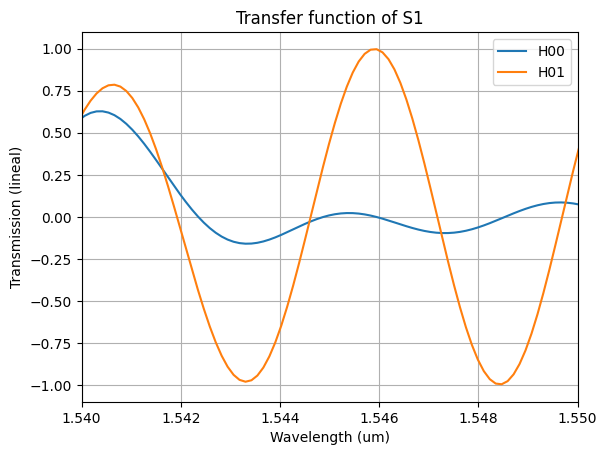

In [17]:
# vemos que las salidas son aproximadamentecomplementarias en un rango ampliado de longitud de onda

plt.figure()
plt.plot(wvl, H00, label="H00")
plt.plot(wvl, H01, label="H01")
plt.xlabel("Wavelength (um)")
plt.ylabel("Transmission (lineal)")
plt.title("Transfer function of S1")
plt.legend()
plt.xlim(1.54,1.55)
plt.grid(True)
plt.show()

##### 3.2) Modelo de S2

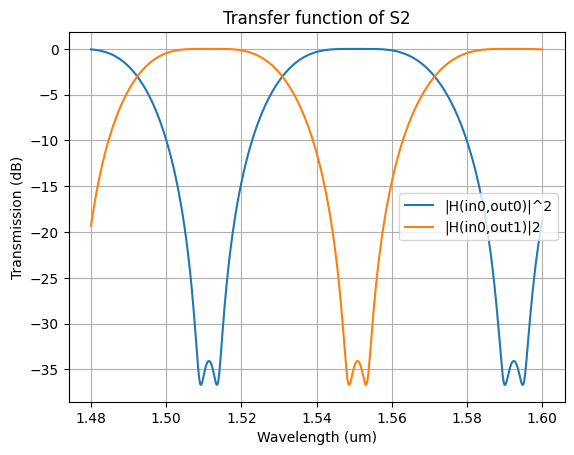

In [18]:
# DESIGN OF S2

L1 = 5
L2 = l2_s2

neffu = neff_450_TE 
neffd = neff_450_TE 

lambda0 = 1.55  # um
n1_1550 = np.interp(lambda0, wvl, neffu)
Lpi = lambda0 / (2*n1_1550)

alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.3)
K_c = np.full(wvl.shape, 0.05)

s2_model, info = sax.circuit(
    netlist={
        "instances": {
            "coup_a": "coupler",
            "wvg_u1": "waveguide",
            "wvg_d1": "waveguide",
            "coup_b": "coupler",

            "mid_u": "waveguide",
            "mid_d": "waveguide",

            "coup_c": "coupler",
        },
        "connections": {
            # Coupler a, b
            "coup_a,out0": "wvg_u1,in0",
            "wvg_u1,out0": "coup_b,in0",
            "coup_a,out1": "wvg_d1,in0",
            "wvg_d1,out0": "coup_b,in1",

            # Coupler b, c
            "coup_b,out0": "mid_u,in0",
            "mid_u,out0": "coup_c,in0",
            "coup_b,out1": "mid_d,in0",
            "mid_d,out0": "coup_c,in1",

        },
        "ports": {
            "in0": "coup_a,in0",
            "in1": "coup_a,in1",
            "out0": "coup_c,out0",
            "out1": "coup_c,out1",
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

total_s2 = s2_model(
    wl=wvl,
    coup_a={"coupling": K_a},
    wvg_u1={"wl": wvl, "neff": neffu, "length": L1, "loss": alphau},
    wvg_d1={"wl": wvl, "neff": neffd, "length": L2, "loss": alphad},
    coup_b={"coupling": K_b},
    mid_d={"wl": wvl, "neff": neffd, "length": 2*L1, "loss": alphad},
    mid_u={"wl": wvl, "neff": neffu, "length": 2*L2, "loss": alphau},
    coup_c={"coupling": K_c},
)

H00 = total_s2["in0", "out0"]
H01 = total_s2["in0", "out1"]
H10 = total_s2["in1", "out0"]
H11 = total_s2["in1", "out1"]

T00_dB = 10*np.log10(np.maximum(np.abs(H00)**2, 1e-12))
T01_dB = 10*np.log10(np.maximum(np.abs(H01)**2, 1e-12))

plt.figure()
plt.plot(wvl, T00_dB, label="|H(in0,out0)|^2")
plt.plot(wvl, T01_dB, label="|H(in0,out1)|2")
plt.xlabel("Wavelength (um)")
plt.ylabel("Transmission (dB)")
plt.title("Transfer function of S2")
plt.legend()
plt.grid(True)
plt.show()

/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


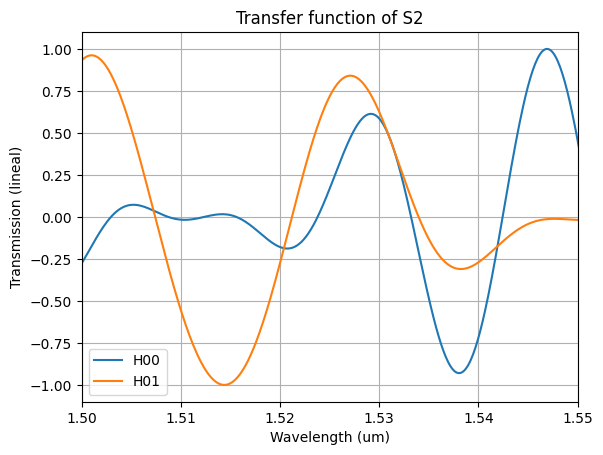

In [19]:
plt.figure()
plt.plot(wvl, H00, label="H00")
plt.plot(wvl, H01, label="H01")
plt.xlabel("Wavelength (um)")
plt.ylabel("Transmission (lineal)")
plt.title("Transfer function of S2")
plt.legend()
plt.xlim(1.50,1.55)
plt.grid(True)
plt.show()

In [20]:
# Definimos las funciones de S1 y S2 para poder usarlas en el diseño de SAX del circuito completo

def s1_function(
    wl=1.55,
    neff=1.6072,
    loss=0,
    l1=10.0,
    l2=10.0,
    k1=0.5,
    k2=0.17,
    k3=0.23,
    k4=0.05,
    lpi=0.0,
) -> sax.SDict:

    total_s1 = s1_model(
        wl=wl,
        coup_a={"coupling": k1},
        wvg_u1={"wl": wl, "neff": neff, "length": l1, "loss": loss},
        wvg_d1={"wl": wl, "neff": neff, "length": l2, "loss": loss},
        coup_b={"coupling": k2},

        mid_u={"wl": wl, "neff": neff, "length": 2*l2, "loss": loss},
        mid_d={"wl": wl, "neff": neff, "length": 2*l1, "loss": loss},

        coup_c={"coupling": k3},

        wvg_u2={"wl": wl, "neff": neff, "length": 2*l2, "loss": loss},
        wvg_d2={"wl": wl, "neff": neff, "length": 2*l1 + lpi, "loss": loss},

        coup_d={"coupling": k4},
    )

    return sax.reciprocal(
        {
            ("in0", "out0"): total_s1["in0", "out0"],
            ("in0", "out1"): total_s1["in0", "out1"],
            ("in1", "out0"): total_s1["in1", "out0"],
            ("in1", "out1"): total_s1["in1", "out1"],
        }
    )


def s2_function(
    wl=1.55,
    neff=1.6072,
    loss=0.0,
    l1=10.0,
    l2=10.0,
    k1=0.5,
    k2=0.3,
    k3=0.05,
) -> sax.SDict:

    total_s2 = s2_model(
        wl=wl,
        coup_a={"coupling": k1},
        wvg_u1={"wl": wl, "neff": neff, "length": l1, "loss": loss},
        wvg_d1={"wl": wl, "neff": neff, "length": l2, "loss": loss},
        coup_b={"coupling": k2},
        mid_u={"wl": wl, "neff": neff, "length": 2*l2, "loss": loss},
        mid_d={"wl": wl, "neff": neff, "length": 2*l1, "loss": loss},
        coup_c={"coupling": k3},
    )

    return sax.reciprocal(
        {
            ("in0", "out0"): total_s2["in0", "out0"],
            ("in0", "out1"): total_s2["in0", "out1"],
            ("in1", "out0"): total_s2["in1", "out0"],
            ("in1", "out1"): total_s2["in1", "out1"],
        }
    )

##### 3.3) Modelo de SAX del circuito completo

In [21]:
# Definimos el circuito de SAX completo usando los modelos de S1 y S2 que hemos definido, y conectando las instancias de S1 y S2 según el esquema del circuito dado.

total_model, info = sax.circuit(
    netlist={
        "instances": {
            # Stage 1
            "S1_inic": "S1",

            # Stage 2
            "S1_top": "S1",
            "S1_bot": "S1",

            # Stage 3
            "S2_top": "S2",
            "S2_bot": "S2",

            # Stage 4 (Output ports)
            "S2_out_1": "S2",
            "S2_out_2": "S2",
            "S2_out_3": "S2",
            "S2_out_4": "S2",
        },
        "connections": {
            # Stage 1 --> Stage 2
            "S1_inic,out0": "S1_top,in1",
            "S1_inic,out1": "S1_bot,in1",

            # Stage 2 --> Stage 3
            "S1_top,out0": "S2_top,in1",
            "S1_bot,out1": "S2_bot,in0",

            # Stage 3 --> Stage 4 (Output ports)
            "S2_top,out0": "S2_out_1,in1",
            "S2_top,out1": "S2_out_2,in0",
            "S2_bot,out0": "S2_out_3,in1",
            "S2_bot,out1": "S2_out_4,in0",
        },
        "ports": {
            # Entrada global
            "in0": "S1_inic,in0",
            "in1": "S1_inic,in1",

            # Salidas globales
            "lambda1": "S2_out_1,out0",
            "lambda2": "S2_out_2,out0",
            "lambda3": "S2_out_3,out1",
            "lambda4": "S2_out_4,out1",
        },
    },
    models={
        "S1": s1_function,
        "S2": s2_function,
    },
)

In [22]:
idx_1540 = np.argmin(np.abs(wvl - 1.540))
Lpi_s1 = float(wvl[idx_1540] / (2 * TE0[idx_1540]))

wvl = np.linspace(1.48, 1.60, 1000) 
TE0 = neff_450_TE
k_s1 = [0.5,0.17,0.23,0.05]
k_s2 = [0.5,0.3,0.05]

S_tree = total_model(
    
    # S1 stages

    S1_inic={
        "wl": wvl,
        "neff": TE0,
        "loss": 0,
        "l1": l1_s1,
        "l2": l2_s1,
        "k1": k_s1[0],
        "k2": k_s1[1],
        "k3": k_s1[2],
        "k4": k_s1[3],
        "lpi": Lpi_s1,
    },

    S1_top={
        "wl": wvl,
        "neff": TE0,
        "loss": 0,
        "l1": l1_s1,
        "l2": l2_s1,
        "k1": k_s1[0],
        "k2": k_s1[1],
        "k3": k_s1[2],
        "k4": k_s1[3],
        "lpi": Lpi_s1,
    },

    S1_bot={
        "wl": wvl,
        "neff": TE0,
        "loss": 0,
        "l1": l1_s1,
        "l2": l2_s1,
        "k1": k_s1[0],
        "k2": k_s1[1],
        "k3": k_s1[2],
        "k4": k_s1[3],
        "lpi": Lpi_s1,
    },

    # S2 upper branch

    S2_top={
        "wl": wvl,
        "neff": TE0,
        "loss": 0,
        "l1": l1_s2,
        "l2": l2_s2,
        "k1": k_s2[0],
        "k2": k_s2[1],
        "k3": k_s2[2],
    },

    S2_out_1={
        "wl": wvl,
        "neff": TE0,
        "loss": 0,
        "l1": l1_s2,
        "l2": l2_s2,
        "k1": k_s2[0],
        "k2": k_s2[1],
        "k3": k_s2[2],
    },

    S2_out_2={
        "wl": wvl,
        "neff": TE0,
        "loss": 0,
        "l1": l1_s2,
        "l2": l2_s2,
        "k1": k_s2[0],
        "k2": k_s2[1],
        "k3": k_s2[2],
    },

    # S2 bottom branch

    S2_bot={
        "wl": wvl,
        "neff": TE0,
        "loss": 0,
        "l1": l1_s2,
        "l2": l2_s2 + despl_s2_b,
        "k1": k_s2[0],
        "k2": k_s2[1],
        "k3": k_s2[2],
    },

    S2_out_3={
        "wl": wvl,
        "neff": TE0,
        "loss": 0,
        "l1": l1_s2,
        "l2": l2_s2 + despl_s2_b,
        "k1": k_s2[0],
        "k2": k_s2[1],
        "k3": k_s2[2],
    },

    S2_out_4={
        "wl": wvl,
        "neff": TE0,
        "loss": 0,
        "l1": l1_s2,
        "l2": l2_s2 + despl_s2_b,
        "k1": k_s2[0],
        "k2": k_s2[1],
        "k3": k_s2[2],
    },
)

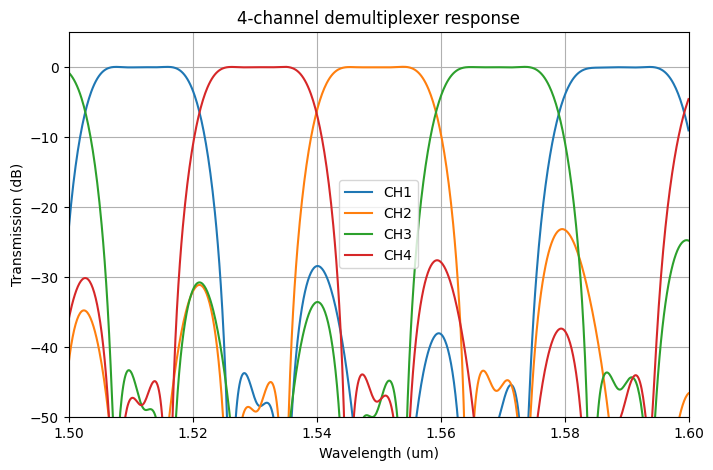

In [23]:
H1 = S_tree["in1", "lambda1"]
H2 = S_tree["in1", "lambda2"]
H3 = S_tree["in1", "lambda3"]
H4 = S_tree["in1", "lambda4"]

T1 = 10*np.log10(np.abs(H1)**2)
T2 = 10*np.log10(np.abs(H2)**2)
T3 = 10*np.log10(np.abs(H3)**2)
T4 = 10*np.log10(np.abs(H4)**2)

plt.figure(figsize=(8, 5))
plt.plot(wvl, T1, label="CH1")
plt.plot(wvl, T2, label="CH2")
plt.plot(wvl, T3, label="CH3")
plt.plot(wvl, T4, label="CH4")

plt.xlim(1.5, 1.6)
plt.ylim(-50, 5)


plt.xlabel("Wavelength (um)")
plt.ylabel("Transmission (dB)")
plt.title("4-channel demultiplexer response")
plt.legend()
plt.grid(True)
plt.show()

## Parte 2) Filter and die layout
### 1) Layout del CWDM (de)multiplexer filter usando GDSFactory

In [24]:
import gdsfactory as gf
from upvfab.sin300.cband import PDK, cells

1.1) Esquemáticos de S1 y S2

In [25]:
# Primero creamos los directional couplers con las longitudes de acoplo que hemos calculado para cada coeficiente de acoplo deseado con un gap entre guías de 0.4um fijo

c_dc1 = cells.coupler(length=16.4409, gap = 0.4)    # acoplo 0.5
c_dc2 = cells.coupler(length=12.1337, gap = 0.4)    # acoplo 0.3
c_dc3 = cells.coupler(length=10.4704, gap = 0.4)    # acoplo 0.23
c_dc4 = cells.coupler(length=8.8964, gap = 0.4)     # acoplo 0.17
c_dc5 = cells.coupler(length=4.7207, gap = 0.4)     # acoplo 0.05

#c_dc1.plot()
#c_dc1.draw_ports()

In [26]:
GAP_DC = 0.4   
LDC = {
    0.50: 16.4409,
    0.30: 12.1337,
    0.23: 10.4704,
    0.17: 8.8964,
    0.05: 4.7207,
}

xs = gf.cross_section.strip(width=0.45, layer="WG")

# longitudes que hemos calculado antes

L1_S1 = l1_s1
L2_S1 = l2_s1
LPI_S1 = Lpi_s1

L1_S2 = l1_s2
L2_S2 = l2_s2
L2_S2_SHIFTED = l2_s2 + despl_s2_b

Usamos el modelo de gdsfactory de mzi_lattice que he revisado de la web de gds:

c = gf.components.mzi_lattice(
    coupler_lengths=coupler_lengths,
    coupler_gaps=coupler_gaps,
    delta_lengths=delta_lengths,
)

In [27]:
# para que no haya errores encontrando el coupler

try:
    mzi_coupler = gf.components.mzi_coupler
except AttributeError:
    from gdsfactory.components.mzis.mzi import mzi_coupler

bend35 = gf.components.bend_euler(radius=35)

# creamos función de directional coupler y la cross section y bend necesarios para el posterior diseño del circuito completo (con distinta width no nos deja usar la función)

xs450 = gf.cross_section.strip(
    width=0.45,
    layer="WG",
)

def bend450(radius=20.0, **kwargs):
    kwargs.pop("cross_section", None)
    return gf.components.bend_euler(
        radius=radius,
        cross_section=xs450,
        **kwargs,
    )

def dc450(length=10.0, gap=0.4, **kwargs):
    kwargs.pop("cross_section", None)
    return gf.components.coupler(
        length=length,
        gap=gap,
        cross_section=xs450,
        **kwargs,
    )

In [28]:
def s1_layout():
    # S1: DC(0.5) - DC(0.17) - DC(0.23) - DC(0.05)

    coupler_lengths = (LDC[0.50], LDC[0.17], LDC[0.23], LDC[0.05])

    coupler_gaps = (GAP_DC, GAP_DC, GAP_DC, GAP_DC)

    # Diferencias de longitud entre brazos para las tres secciones MZI de S1:

    delta_lengths = (L1_S1 - L2_S1, 2 * L1_S1 - 2 * L2_S1, 2 * L1_S1 + LPI_S1 - 2 * L2_S1)

    c = gf.components.mzi_lattice(
        coupler_lengths=coupler_lengths,
        coupler_gaps=coupler_gaps,
        delta_lengths=delta_lengths,
        mzi=mzi_coupler,
        splitter=dc450,
        bend=bend450,
        straight=gf.components.straight,
        cross_section=xs450
    )

    return c

In [29]:
def s2_layout(shifted: bool = False):
    # S2: DC(0.5) - DC(0.3) - DC(0.05)

    # shifted=False: S2 normal.
    # shifted=True: S2 con el desplazamiento de 0.5*Lpi usado en el bloque inferior.
    

    L2 = L2_S2_SHIFTED if shifted else L2_S2

    coupler_lengths = (LDC[0.50], LDC[0.30], LDC[0.05])

    coupler_gaps = (GAP_DC, GAP_DC, GAP_DC)

    # sección 1: upper = L1,  lower = L2
    # sección 2: upper = 2*L2,lower = 2*L1

    delta_lengths = (L2 - L1_S2, 2 * L2 - 2 * L1_S2)

    c = gf.components.mzi_lattice(
        coupler_lengths=coupler_lengths,
        coupler_gaps=coupler_gaps,
        delta_lengths=delta_lengths,
        mzi=mzi_coupler,
        splitter=dc450,
        bend=bend450,
        straight=gf.components.straight,
        cross_section=xs450
    )

    return c

In [41]:
def cwdm_demux_layout_sergi(dx=700, dy=320):
    c = gf.Component()

    # Stage 1
    s1_inic = c << s1_layout()

    # Stage 2
    s1_top = c << s1_layout()
    s1_bot = c << s1_layout()

    s1_top.dmove((dx, +dy))
    s1_bot.dmove((dx, -dy))

    # Stage 3
    s2_top = c << s2_layout(shifted=False)
    s2_bot = c << s2_layout(shifted=True)

    s2_top.dmove((2 * dx, +dy))
    s2_bot.dmove((2 * dx, -dy))

    # Stage 4
    s2_out_1 = c << s2_layout(shifted=False)
    s2_out_2 = c << s2_layout(shifted=False)
    s2_out_3 = c << s2_layout(shifted=True)
    s2_out_4 = c << s2_layout(shifted=True)

    s2_out_1.dmove((3 * dx, +1.8 * dy))
    s2_out_2.dmove((3 * dx, +0.6 * dy))
    s2_out_3.dmove((3 * dx, -0.6 * dy))
    s2_out_4.dmove((3 * dx, -1.8 * dy))

    # Conexiones entre stages:

    route_xs = xs450

    gf.routing.route_single(
        component=c,
        port1=s1_inic.ports["o3"],
        port2=s1_top.ports["o1"],
        cross_section=route_xs,
    )

    gf.routing.route_single(
        component=c,
        port1=s1_inic.ports["o4"],
        port2=s1_bot.ports["o1"],
        cross_section=route_xs,
    )

    gf.routing.route_single(
        component=c,
        port1=s1_top.ports["o3"],
        port2=s2_top.ports["o1"],
        cross_section=route_xs,
    )

    gf.routing.route_single(
        component=c,
        port1=s1_bot.ports["o4"],
        port2=s2_bot.ports["o2"],
        cross_section=route_xs,
    )

    gf.routing.route_single(
        component=c,
        port1=s2_top.ports["o3"],
        port2=s2_out_1.ports["o1"],
        cross_section=route_xs,
    )

    gf.routing.route_single(
        component=c,
        port1=s2_top.ports["o4"],
        port2=s2_out_2.ports["o2"],
        cross_section=route_xs,
    )

    gf.routing.route_single(
        component=c,
        port1=s2_bot.ports["o3"],
        port2=s2_out_3.ports["o1"],
        cross_section=route_xs,
    )

    gf.routing.route_single(
        component=c,
        port1=s2_bot.ports["o4"],
        port2=s2_out_4.ports["o2"],
        cross_section=route_xs,
    )

    # Puertos globales
    c.add_port("in0", port=s1_inic.ports["o1"])
    c.add_port("in1", port=s1_inic.ports["o2"])

    c.add_port("lambda1", port=s2_out_1.ports["o3"])
    c.add_port("lambda2", port=s2_out_2.ports["o3"])
    c.add_port("lambda3", port=s2_out_3.ports["o4"])
    c.add_port("lambda4", port=s2_out_4.ports["o4"])

    return c

2026-05-21 11:10:32.846 | INFO     | kfactory.kcell:show:3995 - klive v0.4.1: Reloaded file '/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab5-finalproject/build/oas/577606660.oas'


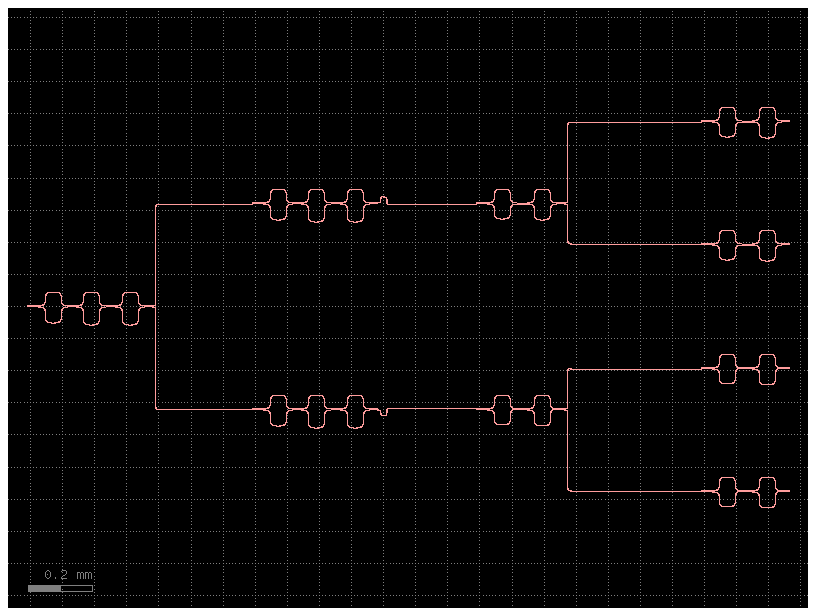

In [42]:
c = gf.Component()
c.add_ref(cwdm_demux_layout_sergi())
c.draw_ports()
c.plot()
c.show()

### Layout of the whole die and test structures

En el layout se han incluido dos copias del circuito. La primera copia incorpora guías de entrada y salida directas al die, mientras que la segunda integra grating couplers rectangulares, lo que permite realizar la caracterización mediante acoplo vertical desde fibra. Además, se han añadido estructuras de test independientes para evaluar parámetros como pérdidas de propagación y elementos individuales del circuito como Directional Couplers, guías rectas o MZIs.

In [43]:
wgw = 0.5 # ancho guias SOI
dieL = 5000
dieW = 5000
border = 125 # espacio entre el borde y el dicing line
layer_wg = "WG"
layer_box = "FLOORPLAN"

# Die specifications (Chip)
box = gf.Component()

obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box)) # caja exterior
ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border) # caja interior (ancho exterior menos 2 veces por el borde)
box = gf.boolean(A=obox, B=ibox, operation="A-B", layer="FLOORPLAN") # restar la caja exterior menos la interior para tener solo el borde

# Adding ports to a component 
box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box) # le metemos un port en el 0,0 para poder referenciarlo todo a el

box.draw_ports()
#box.show()
#box.plot()

In [33]:
@gf.cell 
def die(dieL = 5000, dieW = 5000, border = 250, layer_box = "FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    # Adding ports to a component 
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box

Layout die completo:

2026-05-21 11:05:12.817 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab5-finalproject/build/oas/3920036039.oas'


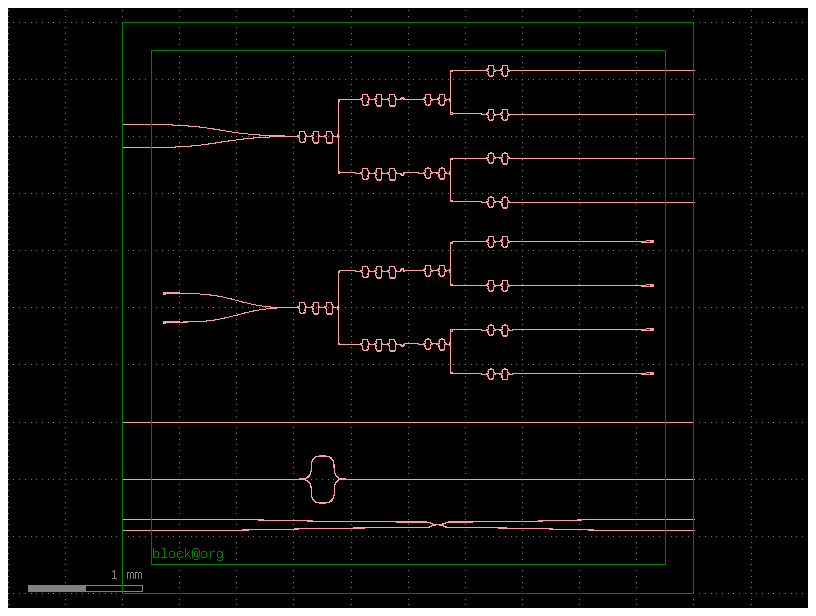

In [34]:
layer_wg  = "WG"
minrad = 50
dieW = 5000

main = gf.Component()

die_ref = main.add_ref(die(dieW = dieW, layer_box="FLOORPLAN"))


# añadimos dos copias del circuito y los posicionamos en el centro del die
demux1 = main.add_ref(cwdm_demux_layout_sergi()).dmovex(die_ref['block@org'].dx + 0.25*dieW).dmovey(die_ref['block@org'].dy + dieW - 125*10)
demux2 = main.add_ref(cwdm_demux_layout_sergi()).dmovex(die_ref['block@org'].dx + 0.25*dieW).dmovey(die_ref['block@org'].dy + dieW - 125*22)

# añadimos guías de acceso a los puertos de entrada y salida de cada circuito, y los conectamos a los puertos del circuito
sp = 200
border = 250

in_arr1 = main.add_ref(gf.components.straight_array(n=2, spacing=sp, length=border, cross_section=xs450)).dmovey(demux1.ports['in1'].y-100)  
out_arr1 = main.add_ref(gf.components.straight_array(n=4, spacing=384, length=border, cross_section=xs450)).dmovex(dieW - border).dmovey(demux1.ports['lambda4'].y)
gf.routing.route_single_sbend(component=main, port1=in_arr1['o3'], port2=demux1['in1'], cross_section=xs450, allow_width_mismatch=True)
gf.routing.route_single_sbend(component=main, port1=in_arr1['o4'], port2=demux1['in0'], cross_section=xs450, allow_width_mismatch=True)
gf.routing.route_single_sbend(component=main, port1=demux1['lambda1'], port2=out_arr1['o4'], cross_section=xs450, allow_width_mismatch=True)
gf.routing.route_single_sbend(component=main, port1=demux1['lambda2'], port2=out_arr1['o3'], cross_section=xs450, allow_width_mismatch=True)
gf.routing.route_single_sbend(component=main, port1=demux1['lambda3'], port2=out_arr1['o2'], cross_section=xs450, allow_width_mismatch=True)
gf.routing.route_single_sbend(component=main, port1=demux1['lambda4'], port2=out_arr1['o1'], cross_section=xs450, allow_width_mismatch=True)


# Segunda copia del demux con grating couplers rectangulares con taper de adaptación GC -> guía xs450

gc = gf.get_component("grating_coupler_rectangular")

gc_port = "o1"

gc_width = gc.ports[gc_port].width
wg_width = 0.45

taper_length = 30

x_gc_in = border+250
x_gc_out = dieW - border-250

# separamos GC de entrada
gc_pitch_in = 250 
y_mid_in = 0.5 * (demux2["in0"].y + demux2["in1"].y)
y_gc_in1 = y_mid_in - 0.5 * gc_pitch_in
y_gc_in0 = y_mid_in + 0.5 * gc_pitch_in

# Entradas del demux2 con GC
# GC a la izquierda, taper ancho -> estrecho

gc_in1 = main.add_ref(gc)
gc_in1.drotate(180)
gc_in1.dmovex(x_gc_in - gc_in1[gc_port].x)
gc_in1.dmovey(y_gc_in1 - gc_in1[gc_port].y)

tp_in1 = main.add_ref(gf.components.taper(length=taper_length,width1=gc_width,width2=wg_width,layer=layer_wg))
tp_in1.connect("o1", gc_in1[gc_port])

gf.routing.route_single_sbend(component=main,port1=tp_in1["o2"],port2=demux2["in1"],cross_section=xs450,)


gc_in0 = main.add_ref(gc)
gc_in0.drotate(180)
gc_in0.dmovex(x_gc_in - gc_in0[gc_port].x)
gc_in0.dmovey(y_gc_in0 - gc_in0[gc_port].y)

tp_in0 = main.add_ref(gf.components.taper(length=taper_length,width1=gc_width,width2=wg_width,layer=layer_wg,))
tp_in0.connect("o1", gc_in0[gc_port])

gf.routing.route_single_sbend(component=main,port1=tp_in0["o2"],port2=demux2["in0"],cross_section=xs450,)

# Salidas del demux2 con GC
# GC a la derecha, taper estrecho -> ancho


gc_l1 = main.add_ref(gc)
gc_l1.dmovex(x_gc_out - gc_l1[gc_port].x)
gc_l1.dmovey(demux2["lambda1"].y - gc_l1[gc_port].y)

tp_l1 = main.add_ref(gf.components.taper(length=taper_length,width1=wg_width,width2=gc_width,layer=layer_wg,))
tp_l1.connect("o2", gc_l1[gc_port])

gf.routing.route_single_sbend(component=main,port1=demux2["lambda1"],port2=tp_l1["o1"],cross_section=xs450,)


gc_l2 = main.add_ref(gc)
gc_l2.dmovex(x_gc_out - gc_l2[gc_port].x)
gc_l2.dmovey(demux2["lambda2"].y - gc_l2[gc_port].y)

tp_l2 = main.add_ref(gf.components.taper(length=taper_length,width1=wg_width,width2=gc_width,layer=layer_wg,))
tp_l2.connect("o2", gc_l2[gc_port])

gf.routing.route_single_sbend(component=main,port1=demux2["lambda2"],port2=tp_l2["o1"],cross_section=xs450,)


gc_l3 = main.add_ref(gc)
gc_l3.dmovex(x_gc_out - gc_l3[gc_port].x)
gc_l3.dmovey(demux2["lambda3"].y - gc_l3[gc_port].y)

tp_l3 = main.add_ref(gf.components.taper(length=taper_length,width1=wg_width,width2=gc_width,layer=layer_wg,))
tp_l3.connect("o2", gc_l3[gc_port])

gf.routing.route_single_sbend(component=main,port1=demux2["lambda3"],port2=tp_l3["o1"],cross_section=xs450,)


gc_l4 = main.add_ref(gc)
gc_l4.dmovex(x_gc_out - gc_l4[gc_port].x)
gc_l4.dmovey(demux2["lambda4"].y - gc_l4[gc_port].y)

tp_l4 = main.add_ref(gf.components.taper(length=taper_length,width1=wg_width,width2=gc_width,layer=layer_wg,))
tp_l4.connect("o2", gc_l4[gc_port])

gf.routing.route_single_sbend(component=main,port1=demux2["lambda4"],port2=tp_l4["o1"],cross_section=xs450,)

# añadimos estructuras de test: 
wvg_test = main.add_ref(gf.components.straight(length=dieW, cross_section=xs450)).dmovey(1500)

in_mzi_test = main.add_ref(gf.components.straight_array(n=1, spacing=100,length=border)).dmovey(1000)
out_mzi_test = main.add_ref(gf.components.straight_array(n=1, spacing=100,length=border)).dmovex(dieW - border).dmovey(1000)
mzi_test = main.add_ref(gf.components.mzi()).dmovex(die_ref['block@org'].dx + 0.25*dieW).dmovey(1000)
gf.routing.route_single_sbend(component=main, port1=in_mzi_test['o2'], port2=mzi_test['o1'], allow_width_mismatch=True)
gf.routing.route_single_sbend(component=main, port1=mzi_test['o2'], port2=out_mzi_test['o1'], allow_width_mismatch=True)

dc_test = cells.coupler(length=LDC[0.5], gap=GAP_DC)
dc_test_ref = main.add_ref(dc_test).dmovex(die_ref['block@org'].dx + 0.5*dieW).dmovey(600)
in_dc_test = main.add_ref(gf.components.straight_array(n=2, spacing=100,length=border)).dmovey(600-50)
out_dc_test = main.add_ref(gf.components.straight_array(n=2, spacing=100,length=border)).dmovex(dieW - border).dmovey(600-50)
gf.routing.route_single_sbend(component = main, port1 = in_dc_test['o3'], port2 = dc_test_ref['o2'], allow_width_mismatch=True)
gf.routing.route_single_sbend(component = main, port1 = in_dc_test['o4'], port2 = dc_test_ref['o1'], allow_width_mismatch=True)
gf.routing.route_single_sbend(component = main, port1 = dc_test_ref['o3'], port2 = out_dc_test['o2'], allow_width_mismatch=True)
gf.routing.route_single_sbend(component = main, port1 = dc_test_ref['o4'], port2 = out_dc_test['o1'], allow_width_mismatch=True)

main.plot()
main.show()